# Multiple linear regression

With several predictors the model becomes

$$Y_i = \beta_0 + \beta_1 x_{i1} + \dots + \beta_p x_{ip} + \varepsilon_i ,$$

where each coefficient $\beta_j$ measures the effect of $x_j$ **while all other predictors are held fixed**. This apparently small change brings new questions, each explored here on a different dataset:

1. **Correlated predictors**: two variables that are each significant alone can both look useless together (catheter length).
2. **Leverage and influence**: which observations have the most weight on the fit, and do they change the conclusions? (savings across countries)
3. **When diagnostics fail**: a group of outliers that standard residual plots cannot detect, and how robust regression handles it (synthetic data).
4. **Categorical predictors and interactions**: dummy variables, different intercepts and different slopes (lathe surface finish).
5. **Factors with many levels**: transformations, partial F-tests and model choice (farm revenue).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings

from diagnostics import diagnostic_plots

warnings.filterwarnings("ignore", message="kurtosistest only valid")
plt.rcParams["figure.dpi"] = 100

## 1. Correlated predictors: catheter length

To examine the heart, a catheter is inserted through a vein. Its optimal length depends on the size of the patient. For 12 children we know height (cm), weight (kg) and the optimal catheter length (cm). Can we predict the length from height and weight?

           height  weight  catlength
height      1.000   0.961      0.881
weight      0.961   1.000      0.894
catlength   0.881   0.894      1.000


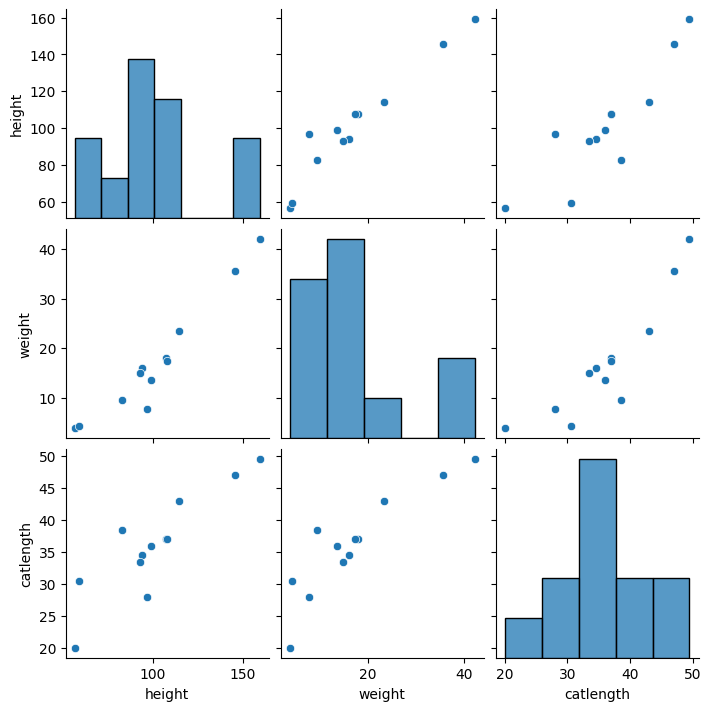

In [2]:
catheter = pd.read_csv("data/catheter.csv")
print(catheter.corr().round(3))
sns.pairplot(catheter, height=2.4)
plt.show()

In [3]:
models = {
    "height only": smf.ols("catlength ~ height", data=catheter).fit(),
    "weight only": smf.ols("catlength ~ weight", data=catheter).fit(),
    "height + weight": smf.ols("catlength ~ height + weight", data=catheter).fit(),
}
pd.DataFrame({
    name: {
        "p-value height": m.pvalues.get("height", np.nan),
        "p-value weight": m.pvalues.get("weight", np.nan),
        "p-value global F-test": m.f_pvalue,
        "R2": m.rsquared,
    }
    for name, m in models.items()
}).round(4)

,height only,weight only,height + weight
p-value height,0.0002,NaN,0.6070
p-value weight,NaN,0.0001,0.2753
p-value global F-test,0.0002,0.0001,0.0006
R2,0.7764,0.7994,0.8056


This looks like a paradox:

- in the **two simple models**, height and weight are both highly significant (p < 0.001);
- in the **multiple model**, neither is significant on its own (p = 0.61 and p = 0.28), yet the global F-test says that *at least one* of them matters (p < 0.001).

There is no contradiction. The t-test of a coefficient in a multiple model asks: *does this predictor add information once the other one is already in the model?* Height and weight are almost perfectly correlated (r = 0.96): once we know a child's height, the weight adds almost nothing new, and vice versa. Each coefficient can be dropped individually, but not both at the same time.

Does the second predictor at least improve predictions? We compute a 95% prediction interval for a child 120 cm tall weighing 25 kg:

In [4]:
child = pd.DataFrame({"height": [120], "weight": [25]})
intervals = pd.DataFrame({
    name: m.get_prediction(child).summary_frame(alpha=0.05)[["mean", "obs_ci_lower", "obs_ci_upper"]].iloc[0]
    for name, m in models.items()
}).T
intervals["width"] = intervals["obs_ci_upper"] - intervals["obs_ci_lower"]
intervals.round(2)

,mean,obs_ci_lower,obs_ci_upper,width
height only,40.66,31.21,50.10,18.89
weight only,41.03,32.06,50.00,17.94
height + weight,40.99,31.54,50.44,18.90


All three models predict about 41 cm, and the multiple model is not more precise: its interval is as wide as the widest of the simple ones. The second predictor brings almost no new information but costs one more parameter estimated from only 12 observations, so the estimation error grows.

More importantly, all intervals are about ±9.5 cm wide, while in practice an error of ±2 cm would be acceptable. With this data, neither height nor weight is enough to choose the catheter length precisely. The model is statistically significant, but not useful for the clinical purpose.

## 2. Leverage and influence: savings across countries

The savings dataset describes 50 countries, averaged over 1960–1970:

- `sr`: savings rate (share of disposable income that is saved);
- `pop15`, `pop75`: share of the population younger than 15 and older than 75;
- `dpi`: per-capita disposable income;
- `ddpi`: growth rate of `dpi`.

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     28.5661      7.355      3.884      0.000      13.753      43.379
pop15         -0.4612      0.145     -3.189      0.003      -0.753      -0.170
pop75         -1.6915      1.084     -1.561      0.126      -3.874       0.491
dpi           -0.0003      0.001     -0.362      0.719      -0.002       0.002
ddpi           0.4097      0.196      2.088      0.042       0.015       0.805


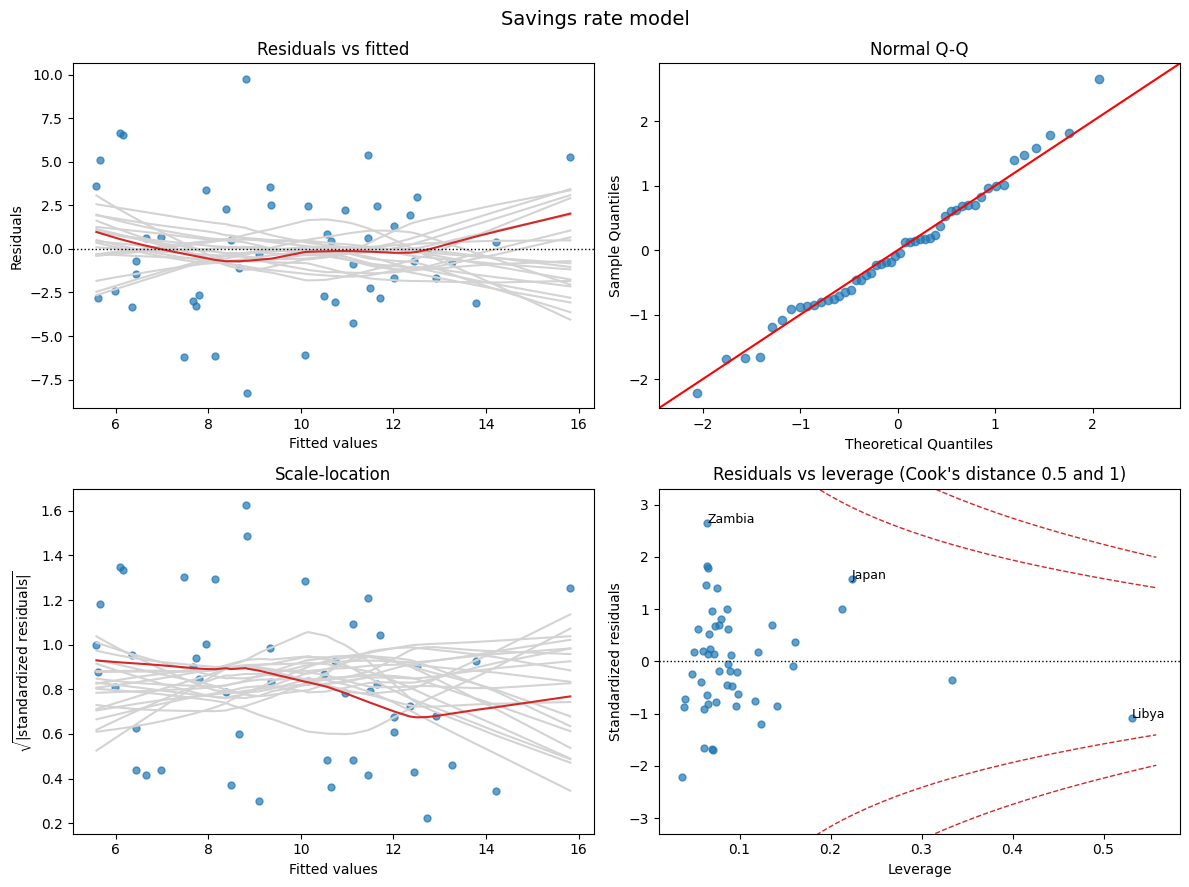

In [5]:
savings = pd.read_csv("data/savings.csv", index_col=0)
savings_fit = smf.ols("sr ~ pop15 + pop75 + dpi + ddpi", data=savings).fit()
print(savings_fit.summary().tables[1])
diagnostic_plots(savings_fit, title="Savings rate model")

The residual plots show no serious violation of the assumptions. Some countries have high **leverage** (an unusual combination of predictor values), but none of them exceeds a Cook's distance of 0.5, so no single country dominates the fit.

Which countries have the highest leverage, and why?

In [6]:
influence = savings_fit.get_influence().summary_frame()[["hat_diag", "cooks_d", "standard_resid"]]
top = influence.sort_values("hat_diag", ascending=False).head(3)
top.round(3)

,hat_diag,cooks_d,standard_resid
Libya,0.531,0.268,-1.087
United States,0.334,0.013,-0.358
Japan,0.223,0.143,1.576


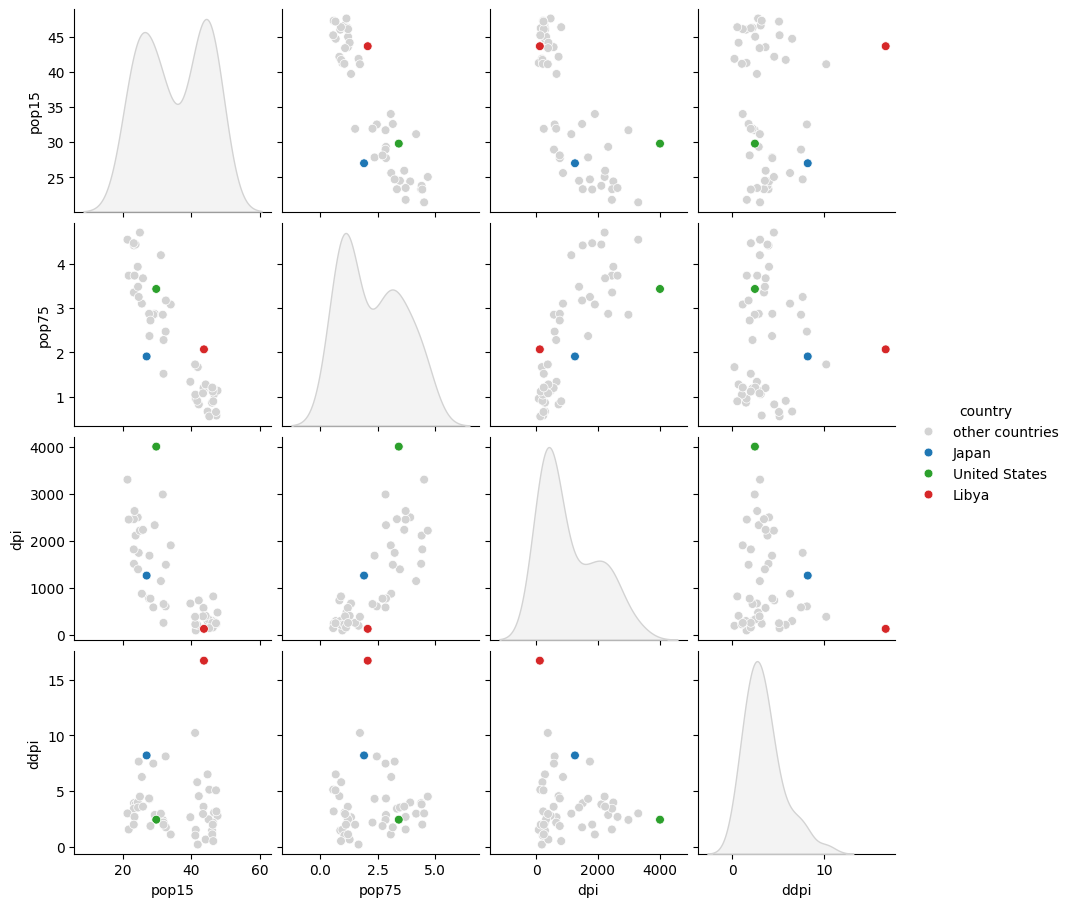

In [7]:
labels = pd.Series("other countries", index=savings.index)
labels[top.index] = top.index
sns.pairplot(savings.assign(country=labels), hue="country", vars=["pop15", "pop75", "dpi", "ddpi"],
             palette={"other countries": "lightgrey", **dict(zip(top.index, ["tab:red", "tab:green", "tab:blue"]))},
             height=2.3, plot_kws={"s": 40})
plt.show()

- **Libya** has a very low income (`dpi`) combined with by far the highest income growth (`ddpi`).
- The **United States** has the highest income of all countries and a relatively old population.
- **Japan** is not extreme in any single variable, but it sits at the edge of the cloud in several plots at once: high growth with a young population.

Libya is also the country with the largest Cook's distance. Does removing it change the conclusions?

In [8]:
without_libya = smf.ols("sr ~ pop15 + pop75 + dpi + ddpi", data=savings.drop(index="Libya")).fit()
pd.DataFrame({
    "coef (all)": savings_fit.params, "p (all)": savings_fit.pvalues,
    "coef (no Libya)": without_libya.params, "p (no Libya)": without_libya.pvalues,
}).round(4)

,coef (all),p (all),coef (no Libya),p (no Libya)
Intercept,28.5661,0.0003,24.5240,0.0047
pop15,-0.4612,0.0026,-0.3914,0.0171
pop75,-1.6915,0.1255,-1.2809,0.2694
dpi,-0.0003,0.7192,-0.0003,0.7331
ddpi,0.4097,0.0425,0.6103,0.0281


The coefficients change somewhat, mostly for `ddpi`, whose estimate relied on Libya's extreme value, but the signs, the magnitudes and the set of significant predictors stay the same. **High leverage is not the same as high influence**: Libya is an unusual country, but it lies close enough to the fitted plane that removing it does not change the story.

## 3. When diagnostics fail: a hidden group of outliers

The next dataset has a response `y` and two predictors `x1`, `x2`. We know that most observations follow a linear model with normal errors. Let us fit a regression and look at the residuals as usual.

Intercept    72.902
x1           -2.084
x2            1.426
dtype: float64


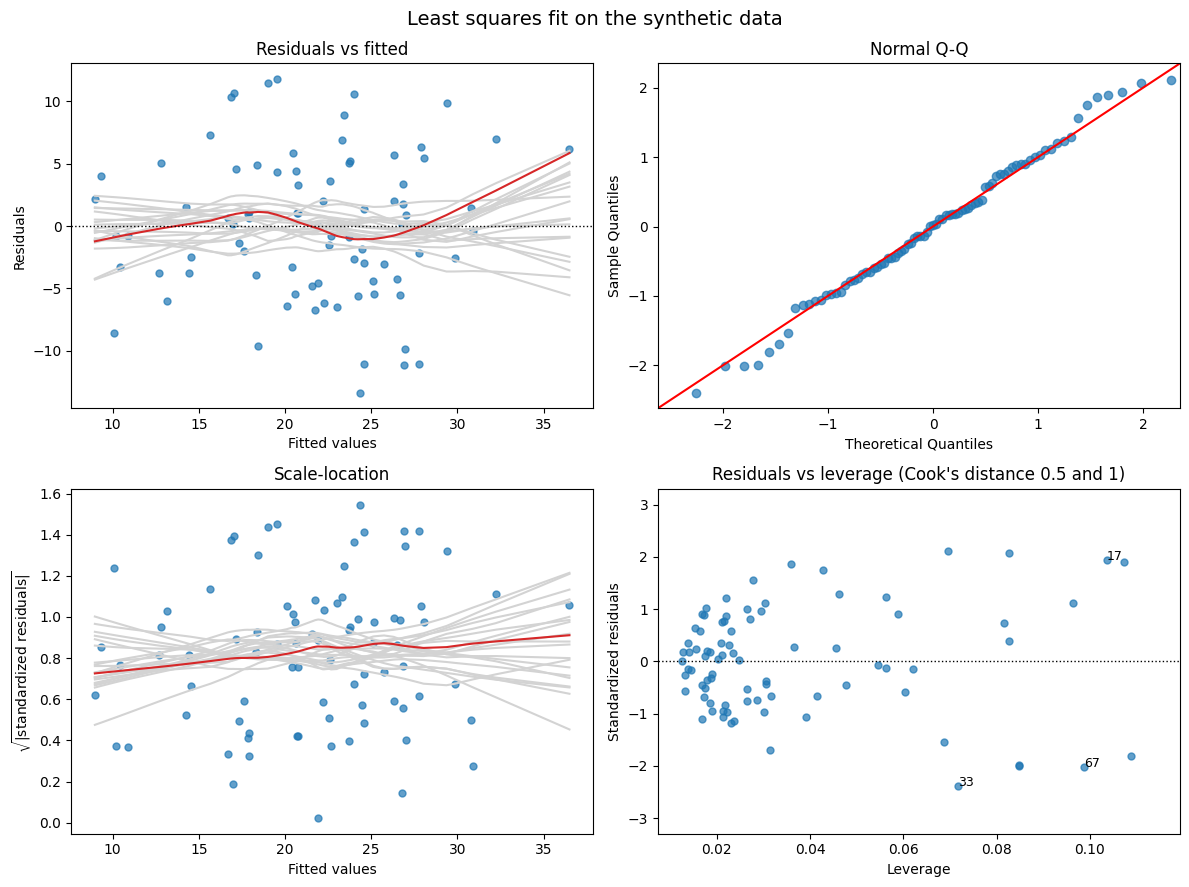

In [9]:
synthetic = pd.read_csv("data/synthetic.csv", index_col=0)
synthetic_fit = smf.ols("y ~ x1 + x2", data=synthetic).fit()
print(synthetic_fit.params.round(3))
diagnostic_plots(synthetic_fit, title="Least squares fit on the synthetic data")

Nothing alarming: a slight curvature in the Tukey-Anscombe plot, slightly increasing variance, and no observation with a large Cook's distance. By the usual standards we would accept this model.

A 3D view tells a different story:

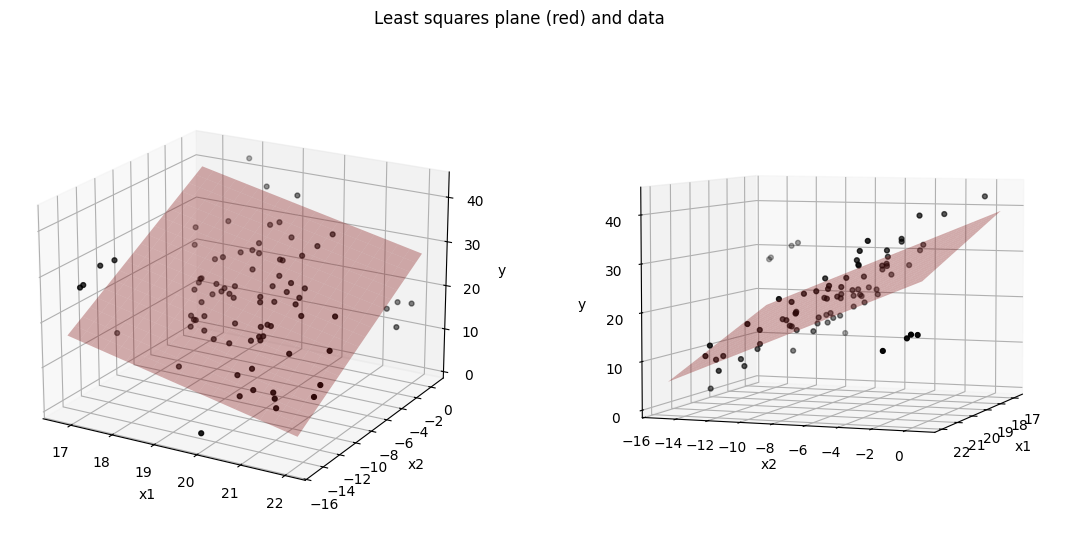

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3D projection)

def plane(params, g1, g2):
    return params["Intercept"] + params["x1"] * g1 + params["x2"] * g2

g1, g2 = np.meshgrid(np.linspace(synthetic["x1"].min(), synthetic["x1"].max(), 20),
                     np.linspace(synthetic["x2"].min(), synthetic["x2"].max(), 20))

fig = plt.figure(figsize=(14, 6))
for k, (azim, elev) in enumerate([(-60, 20), (20, 5)], start=1):
    ax = fig.add_subplot(1, 2, k, projection="3d")
    ax.plot_surface(g1, g2, plane(synthetic_fit.params, g1, g2), alpha=0.35, color="tab:red")
    ax.scatter(synthetic["x1"], synthetic["x2"], synthetic["y"], color="black", s=12)
    ax.set(xlabel="x1", ylabel="x2", zlabel="y")
    ax.view_init(elev=elev, azim=azim)
fig.suptitle("Least squares plane (red) and data")
plt.show()

Two small groups of points sit at the two extremes of `x1`, on opposite sides of the main cloud: high `y` for small `x1` and low `y` for large `x1`. Least squares tries to accommodate every point, so these two groups tilt the plane and reverse the trend in `x1`. The result is a compromise plane that fits nothing particularly well, but nothing particularly badly either. That is why every residual looks ordinary.

Cook's distance fails here because it measures what happens when **one** observation is removed: with a whole group of outliers, removing any single one of them changes almost nothing.

**Robust regression** methods reduce the weight of observations with large residuals. Here we use an M-estimator with Tukey's biweight function, which gives zero weight to points that are far from the fit:

In [11]:
X = sm.add_constant(synthetic[["x1", "x2"]]).rename(columns={"const": "Intercept"})
robust_fit = sm.RLM(synthetic["y"], X, M=sm.robust.norms.TukeyBiweight()).fit()
weights = pd.Series(robust_fit.weights, index=synthetic.index)

pd.DataFrame({"least squares": synthetic_fit.params, "robust (Tukey biweight)": robust_fit.params}).round(3)

,least squares,robust (Tukey biweight)
Intercept,72.902,6.520
x1,-2.084,1.908
x2,1.426,2.951


Observations given (almost) zero weight: 8 of 83


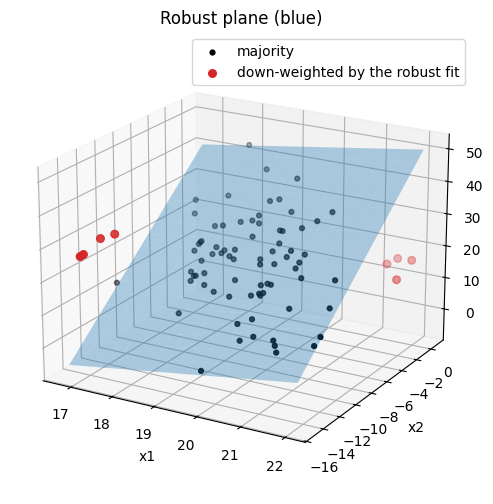

In [12]:
outliers = weights < 0.1
print(f"Observations given (almost) zero weight: {outliers.sum()} of {len(weights)}")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(g1, g2, plane(robust_fit.params, g1, g2), alpha=0.35, color="tab:blue")
ax.scatter(*synthetic.loc[~outliers, ["x1", "x2", "y"]].T.values, color="black", s=12, label="majority")
ax.scatter(*synthetic.loc[outliers, ["x1", "x2", "y"]].T.values, color="tab:red", s=30, label="down-weighted by the robust fit")
ax.set(xlabel="x1", ylabel="x2", zlabel="y", title="Robust plane (blue)")
ax.view_init(elev=20, azim=-60)
ax.legend()
plt.show()

The robust fit finds the plane followed by the majority of the data, with completely different coefficients (the effect of `x1` even changes sign), and isolates the 8 observations that do not belong to it.

**Takeaway:** residual plots can only reveal problems that least squares leaves in the residuals. When outliers come in groups, they pull the fit towards themselves and hide. With several predictors, fitting a robust model alongside least squares is a cheap and effective check.

## 4. Categorical predictors and interactions: lathe surface finish

An engineer measured the surface quality `Q` of 20 metal parts machined on a lathe at different speeds `S` (revolutions per minute) with one of two cutting tools, `DM302` or `DM416`.

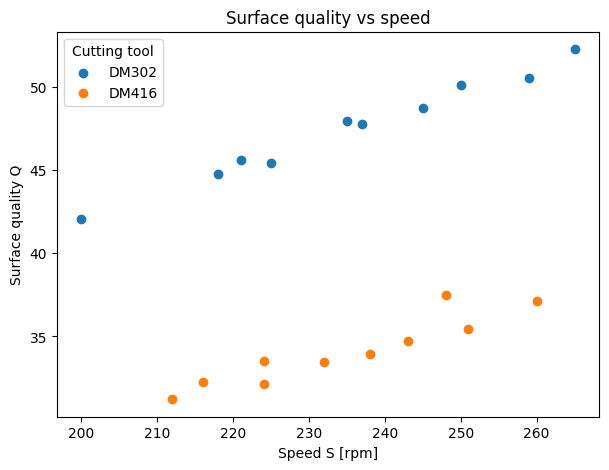

In [13]:
lathe = pd.read_csv("data/lathe.csv")

fig, ax = plt.subplots(figsize=(7, 5))
for tool, group in lathe.groupby("CTT"):
    ax.scatter(group["S"], group["Q"], label=tool)
ax.set(xlabel="Speed S [rpm]", ylabel="Surface quality Q", title="Surface quality vs speed")
ax.legend(title="Cutting tool")
plt.show()

The points follow two almost parallel lines, one per tool. A categorical predictor enters the model through a **dummy variable** $D$ ($D = 1$ for tool DM416, $D = 0$ for DM302):

$$Q = \beta_0 + \beta_1 S + \beta_2 D + \varepsilon \quad\Longrightarrow\quad
\begin{cases} \text{DM302:} & Q = \beta_0 + \beta_1 S \\ \text{DM416:} & Q = (\beta_0 + \beta_2) + \beta_1 S \end{cases}$$

Both tools share the slope $\beta_1$, while $\beta_2$ shifts the intercept. The formula interface creates the dummy automatically with `C(CTT)`.

In [14]:
parallel = smf.ols("Q ~ S + C(CTT)", data=lathe).fit()
print(parallel.summary().tables[1])

                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          14.2762      2.091      6.827      0.000       9.864      18.688
C(CTT)[T.DM416]   -13.2802      0.303    -43.847      0.000     -13.919     -12.641
S                   0.1411      0.009     15.979      0.000       0.123       0.160


To let each tool have its own slope as well, we add the **interaction** between speed and tool:

$$Q = \beta_0 + \beta_1 S + \beta_2 D + \beta_3 \, S \cdot D + \varepsilon \quad\Longrightarrow\quad \text{DM416:} \ Q = (\beta_0 + \beta_2) + (\beta_1 + \beta_3) S$$

Now $\beta_3$ is the difference between the two slopes.

In [15]:
interaction = smf.ols("Q ~ S * C(CTT)", data=lathe).fit()
print(interaction.summary().tables[1])

                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            11.5029      2.504      4.593      0.000       6.194      16.812
C(CTT)[T.DM416]      -6.0942      4.025     -1.514      0.149     -14.626       2.437
S                     0.1529      0.011     14.428      0.000       0.130       0.175
S:C(CTT)[T.DM416]    -0.0306      0.017     -1.790      0.092      -0.067       0.006


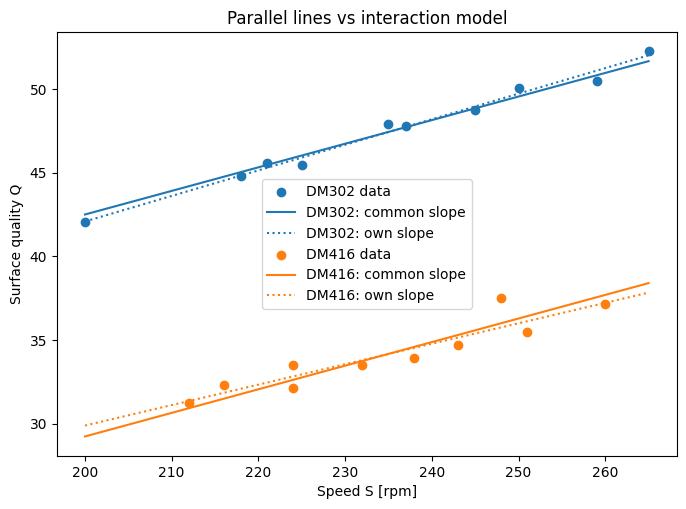

In [16]:
grid = np.linspace(lathe["S"].min(), lathe["S"].max(), 50)
fig, ax = plt.subplots(figsize=(8, 5.5))
for tool, color in [("DM302", "tab:blue"), ("DM416", "tab:orange")]:
    group = lathe[lathe["CTT"] == tool]
    new = pd.DataFrame({"S": grid, "CTT": tool})
    ax.scatter(group["S"], group["Q"], color=color, label=f"{tool} data")
    ax.plot(grid, parallel.predict(new), color=color, label=f"{tool}: common slope")
    ax.plot(grid, interaction.predict(new), color=color, ls=":", label=f"{tool}: own slope")
ax.set(xlabel="Speed S [rpm]", ylabel="Surface quality Q", title="Parallel lines vs interaction model")
ax.legend()
plt.show()

With the interaction, the slope for DM416 is 0.031 lower than for DM302 (0.122 vs 0.153). Is this difference real? The test of $H_0: \beta_3 = 0$ gives p = 0.092: the difference is **not significant at the 5% level** (it would be at 10%). The data are compatible with parallel lines, and the simpler model is preferred.

Not rejecting $H_0$ does not prove that the slopes are equal. With only 20 parts, a small but real difference could go undetected (a type II error). We cannot quantify that risk without assuming a specific size for the true difference; a larger experiment would be needed to settle the question.

## 5. Factors with many levels: farm revenue

A survey collected data on 451 farms: total `revenue`, total `costs`, the `region` (6 codes) and the type of `industry` (1 = wheat, 2 = wheat/sheep/cattle, 3 = sheep, 4 = cattle, 5 = sheep/cattle).

`region` and `industry` are stored as integers but they are **labels**, not quantities: treating them as numbers would force, for example, industry 4 to have twice the effect of industry 2. They must enter the model as factors, which become a set of dummy variables. Each level should also have enough observations to estimate its own coefficient:

In [17]:
farm = pd.read_csv("data/farm.csv")
print("observations per region:  ", farm["region"].value_counts().sort_index().to_dict())
print("observations per industry:", farm["industry"].value_counts().sort_index().to_dict())

observations per region:   {111: 30, 121: 95, 122: 103, 123: 108, 131: 81, 132: 34}
observations per industry: {1: 37, 2: 137, 3: 100, 4: 86, 5: 91}


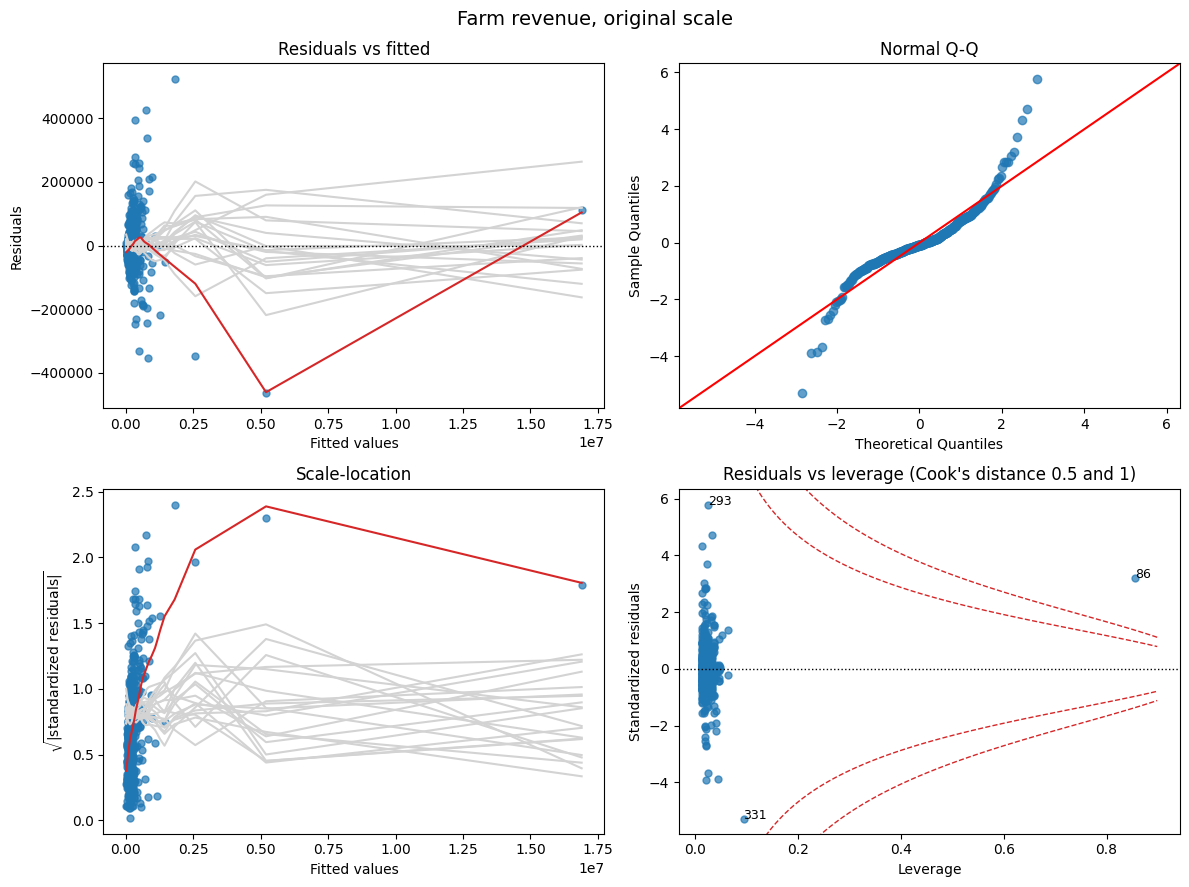

In [18]:
farm_raw = smf.ols("revenue ~ costs + C(region) + C(industry)", data=farm).fit()
diagnostic_plots(farm_raw, title="Farm revenue, original scale")

On the original scale the assumptions are clearly violated: the residuals fan out as revenue grows, the Q-Q plot has very heavy tails, and a few large farms dominate the fit. Revenue and costs are positive, right-skewed monetary amounts, which is the textbook case for a log transformation.

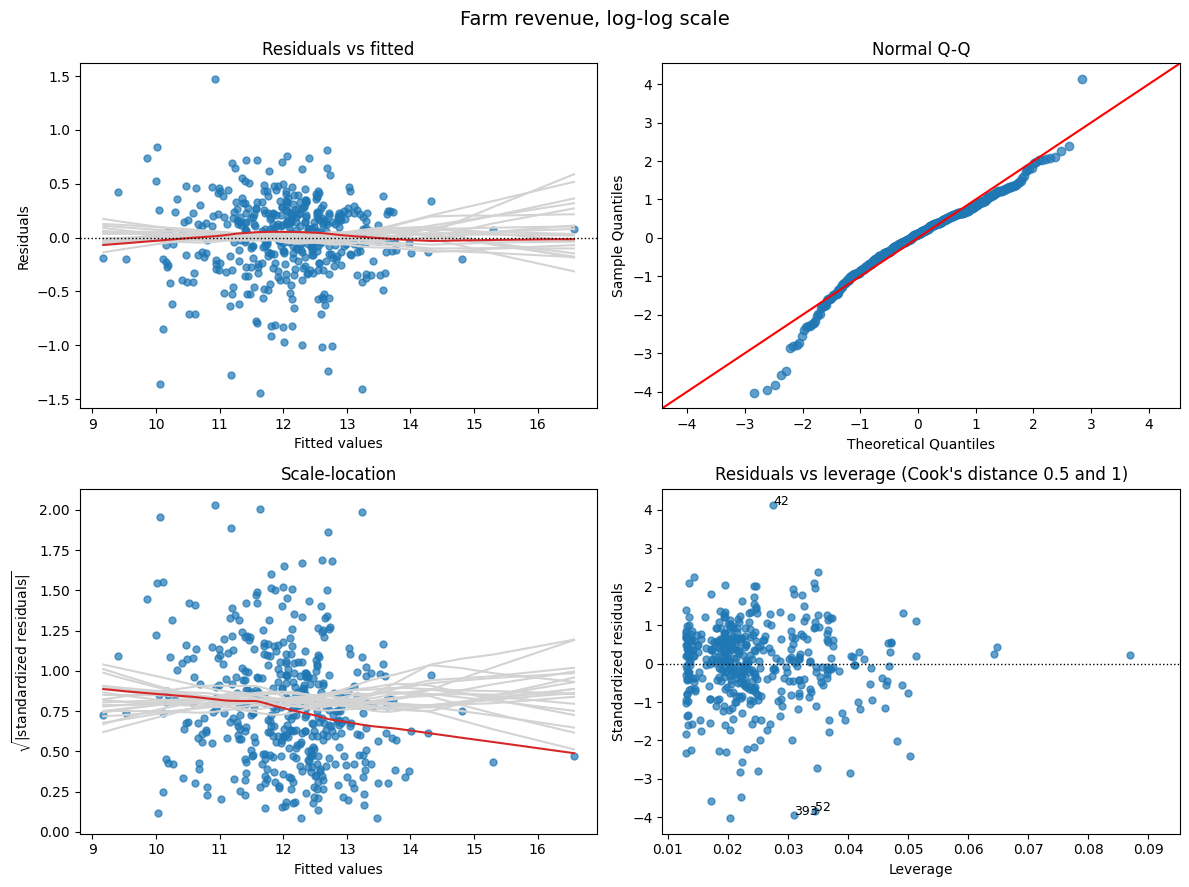

In [19]:
farm_log = smf.ols("np.log(revenue) ~ np.log(costs) + C(region) + C(industry)", data=farm).fit()
diagnostic_plots(farm_log, title="Farm revenue, log-log scale")

After the transformation the Tukey-Anscombe plot shows no systematic pattern and the spread is roughly constant. The residual distribution is still somewhat skewed to the left, with a few farms whose revenue is far from what their costs suggest (in both directions), but the assumptions now hold well enough to continue.

### Prediction

Expected revenue for a cattle farm (industry 4) in region 111 with costs of 100,000:

In [20]:
new_farm = pd.DataFrame({"costs": [100_000], "region": [111], "industry": [4]})
pred = np.exp(farm_log.get_prediction(new_farm).summary_frame(alpha=0.05))
print(f"Predicted revenue: {pred['mean'].iloc[0]:,.0f}")
print(f"95% prediction interval: {pred['obs_ci_lower'].iloc[0]:,.0f} - {pred['obs_ci_upper'].iloc[0]:,.0f}")

Predicted revenue: 154,914
95% prediction interval: 74,808 - 320,800


Since the model is on the log scale, the back-transformed prediction estimates the **median** revenue rather than the mean, and the prediction interval is asymmetric, as is natural for a positive amount.

### Does region matter? Partial F-tests

A factor corresponds to several coefficients at once (5 dummies for region), so the right question is not whether any single dummy is significant, but whether all of them together improve the model. This is answered by a **partial F-test**, which compares the model with and without the factor:

In [21]:
sm.stats.anova_lm(farm_log, typ=2).round(4)

,sum_sq,df,F,PR(>F)
C(region),1.3639,5.0,2.0906,0.0655
C(industry),2.7665,4.0,5.3007,0.0004
np.log(costs),317.2079,1.0,2431.0923,0.0000
Residual,57.4110,440.0,NaN,NaN


Costs and industry are clearly significant, while region is not (p ≈ 0.066): once costs and type of farming are known, the region adds little.

Could the effect of the industry depend on the region? That is an **interaction** between the two factors. It adds many parameters, so we check that the data can support it and test it as a whole:

In [22]:
farm_inter = smf.ols("np.log(revenue) ~ np.log(costs) + C(region) * C(industry)", data=farm).fit()
print(f"parameters: {len(farm_inter.params)}, residual degrees of freedom: {int(farm_inter.df_resid)}")
sm.stats.anova_lm(farm_inter, typ=2).round(4)

parameters: 31, residual degrees of freedom: 420


,sum_sq,df,F,PR(>F)
C(region),1.3639,5.0,2.1006,0.0644
C(industry),2.7665,4.0,5.3260,0.0003
C(region):C(industry),2.8706,20.0,1.1053,0.3404
np.log(costs),303.4669,1.0,2336.9109,0.0000
Residual,54.5404,420.0,NaN,NaN


The interaction model estimates 31 parameters from 451 farms, which is still reasonable, but the interaction is not significant: the effect of the type of farming does not change across regions.

### Choosing the model

From the most complex to the simplest, the candidates are: interaction model → main effects (costs, region, industry) → costs and industry only. Neither the interaction nor region adds significant information, so we keep the simplest model:

In [23]:
farm_final = smf.ols("np.log(revenue) ~ np.log(costs) + C(industry)", data=farm).fit()
comparison = sm.stats.anova_lm(farm_final, farm_log, farm_inter)
comparison.index = ["costs + industry", "+ region", "+ region x industry"]
print(comparison.round(4))
print()
print(farm_final.summary().tables[1])

                     df_resid      ssr  df_diff  ss_diff       F  Pr(>F)
costs + industry        445.0  58.7749      0.0      NaN     NaN     NaN
+ region                440.0  57.4110      5.0   1.3639  2.1006  0.0643
+ region x industry     420.0  54.5404     20.0   2.8706  1.1053  0.3404

                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.1749      0.227      5.166      0.000       0.728       1.622
C(industry)[T.2]    -0.1469      0.067     -2.179      0.030      -0.279      -0.014
C(industry)[T.3]    -0.1985      0.070     -2.830      0.005      -0.336      -0.061
C(industry)[T.4]    -0.0283      0.074     -0.384      0.701      -0.173       0.117
C(industry)[T.5]    -0.1493      0.071     -2.099      0.036      -0.289      -0.010
np.log(costs)        0.9294      0.018     51.712      0.000       0.894       0.965


The final model explains log-revenue with log-costs and the type of farming. The coefficient of `np.log(costs)` is an elasticity: a 1% increase in costs comes with about a 0.93% increase in revenue, for every type of farm. The industry dummies shift the level: compared with wheat farms (industry 1), mixed and sheep farms earn about 14–18% less for the same costs.

## Summary

- In a multiple model each coefficient is a **partial effect**. Strongly correlated predictors make the individual tests unreliable, even when the global F-test is clearly significant.
- **Leverage** measures how unusual the predictors of an observation are; **influence** (Cook's distance) measures how much it actually changes the fit. The two are not the same thing.
- Standard diagnostics can miss **groups of outliers**. A robust fit is a cheap and effective cross-check.
- **Categorical predictors** become dummy variables; **interactions** let the slope of one predictor depend on another.
- Factors are tested as a whole with **partial F-tests**, and the final model should be the simplest one that the data support.